In [ ]:
%load_ext autoreload
%autoreload 2

import argparse
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import mplhep
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

from analysis.utils.datasets import CNNProjectionDatasetFaser
from analysis.utils.geometry import Geometry, get_rebinned_geometry

# from analysis.utils.networks import ClassifierProjectionCNN
from analysis.utils.models import ClassifierProjectionCNNFaser
from analysis.utils.plot_utils import setup
from analysis.utils.torch_data_utils import evaluate_model
from analysis.utils.torch_utils import (
    get_device,
    load_weights,
    show_model,
    train,
)
from analysis.utils.truth import TruthParticle, get_truth_particle
from analysis.utils.units import um
from analysis.utils.utils import (
    get_figures_path,
    get_npy_path,
    get_parquet_path,
    get_torch_path,
    get_weights_path,
)
from analysis.utils.validation_utils import (
    get_accuracy_dict,
    plot_confusion_matrix,
    plot_precision_recall_curve,
    plot_probabilities,
    plot_roc_curve,
    plot_training_metrics,
)

/Users/tboeckh/Library/Caches/pypoetry/virtualenvs/analysis-mEzhAUyO-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
setup()

In [3]:
@dataclass
class NuType:
    idx: int
    label: str
    latex_name: str


nue = NuType(0, "nue", r"CC $\nu_{e}$")
num = NuType(1, "num", r"CC $\nu_{\mu}$")
nun = NuType(2, "nun", "NC")
nus = [nue, num, nun]

In [4]:
feature_dim: int = 128
geometry_label = "cnn_projection_faser_200um_bins_10000_10003"
# geometry_label = "theta_100mrad_ratio_10"
# geometry_label = "./"
torch_path = get_torch_path() / geometry_label / "cnn.pt"
weights_path = get_weights_path() / geometry_label
figures_path = get_figures_path() / geometry_label

dataset = torch.load(torch_path, weights_only=False, map_location="cpu")

# _, test_indices = train_test_split(
#     range(len(dataset)), test_size=0.1, random_state=42, stratify=dataset.labels
# )
# test_dataset = torch.utils.data.subset(dataset, test_indices)
test_dataset = dataset
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, pin_memory=True)

device = get_device()

model = ClassifierProjectionCNNFaser(feature_dim=feature_dim, num_classes=3)
model = model.to(device)

load_weights(model, device, weights_path / "model_weights.pth")

Using device: cpu


In [5]:
y_true, y_pred, y_prob = evaluate_model(
    model=model, test_loader=test_loader, device=device
)

Evaluating: 100%|██████████| 167/167 [00:57<00:00,  2.89it/s]


In [6]:
acc_dict = get_accuracy_dict(
    y_true=y_true, y_pred=y_pred, class_names=[nu.label for nu in nus]
)
for label, acc in acc_dict.items():
    print(f"{label}: {acc * 100:.1f}%")

nue: 68.9%
num: 82.0%
nun: 34.0%
average: 61.7%


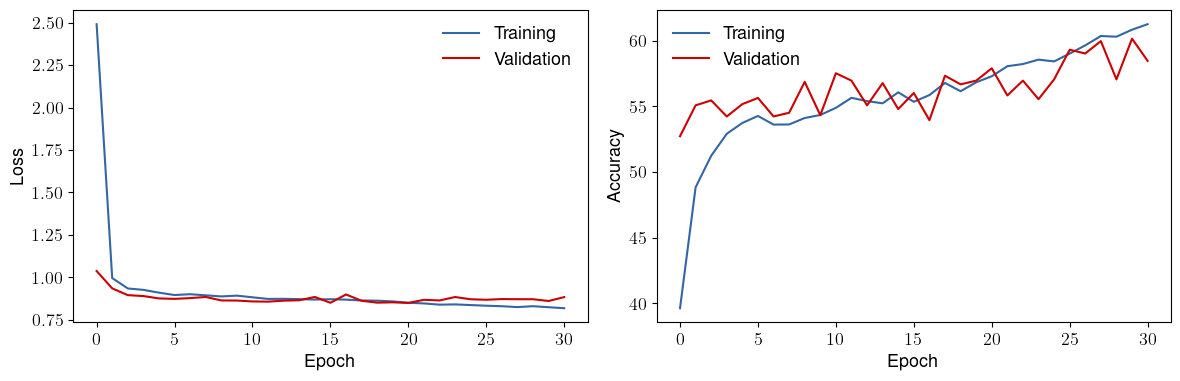

In [7]:
plot_training_metrics(weights_path / "training_metrics.npz")

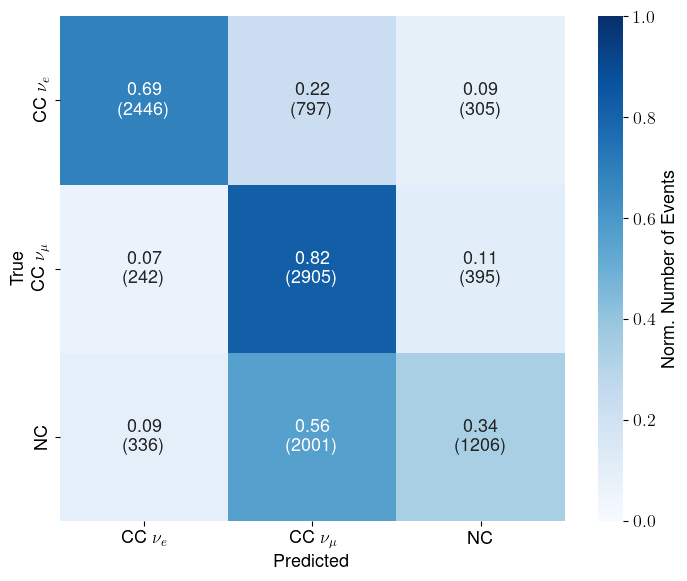

In [8]:
plot_confusion_matrix(
    y_true, y_pred, normalize=True, class_names=[nu.latex_name for nu in nus]
)

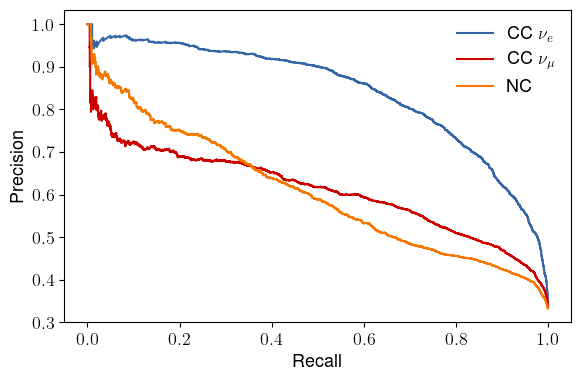

In [9]:
plot_precision_recall_curve(
    y_true=y_true, y_prob=y_prob, class_names=[nu.latex_name for nu in nus]
)

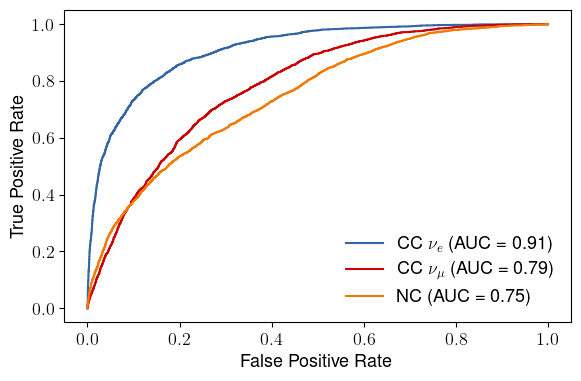

In [11]:
plot_roc_curve(
    y_true=y_true,
    y_prob=y_prob,
    class_names=[nu.latex_name for nu in nus],
    figure_path=figures_path / "roc_curve.png",
)

3548.0
3548.0
3548.0


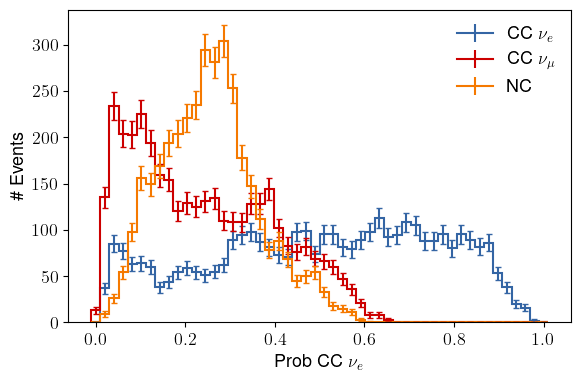

3542.0
3542.0
3542.0


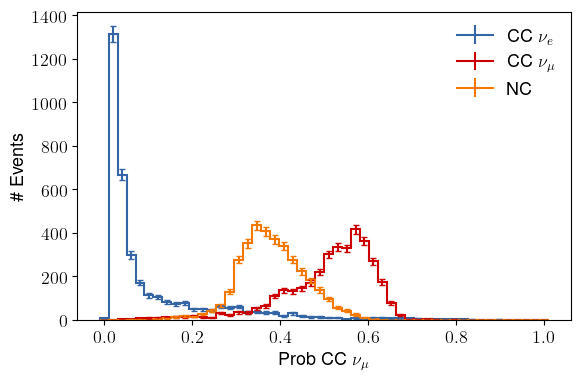

3543.0
3543.0
3543.0


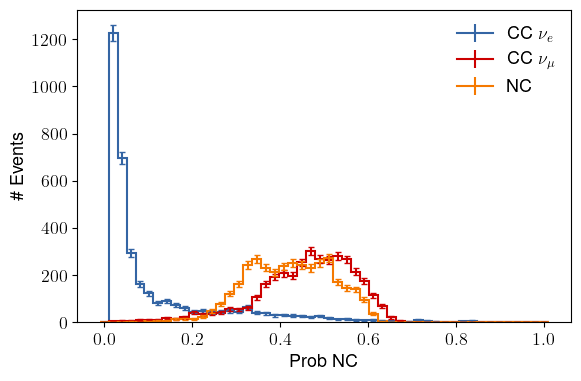

In [12]:
plot_probabilities(
    y_true=y_true, y_prob=y_prob, class_names=[nu.latex_name for nu in nus]
)

In [17]:
truth_df = pd.read_parquet(
    get_torch_path() / geometry_label / "cnn_projection_faser_truth.parq"
)

In [18]:
truth_df.loc[:, "E_nu_bin"] = pd.cut(
    truth_df["E_nu"], bins=np.arange(0, 1200e3 + 1e-3, 100e3), labels=False
)

In [19]:
num_events = len(dataset)
e_nu = np.zeros(num_events)
for i in range(num_events):
    e_nu[i] = dataset[i][1]["E_nu"]
e_nu = np.array(e_nu)

In [20]:
nu_energy_edges = np.arange(0, 1200e3 + 1e-3, 100e3)
nu_energy_centers = (nu_energy_edges[:-1] + nu_energy_edges[1:]) / 2
e_nu_bins = pd.cut(e_nu, bins=nu_energy_edges, labels=False)

In [21]:
acc_dicts = []
for i in range(12):
    bin_indices = indices = np.where(e_nu_bins == i)[0]
    y_true_bin = y_true[bin_indices]
    y_pred_bin = y_pred[bin_indices]
    acc_dict = get_accuracy_dict(
        y_true=y_true_bin, y_pred=y_pred_bin, class_names=[nu.label for nu in nus]
    )
    acc_dicts.append(acc_dict)

In [22]:
combined_acc_dict = {}
for key in ["nue", "num", "nun", "average"]:
    combined_acc_dict[key] = [acc_dict[key] for acc_dict in acc_dicts]
acc_df = pd.DataFrame(combined_acc_dict)
acc_df.loc[:, "energy"] = nu_energy_centers * 1e-3

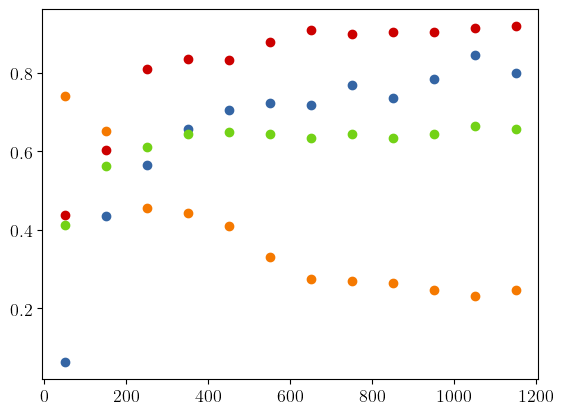

In [23]:
fig, ax = plt.subplots()
for key in ["nue", "num", "nun", "average"]:
    plt.scatter(acc_df["energy"], acc_df[key])

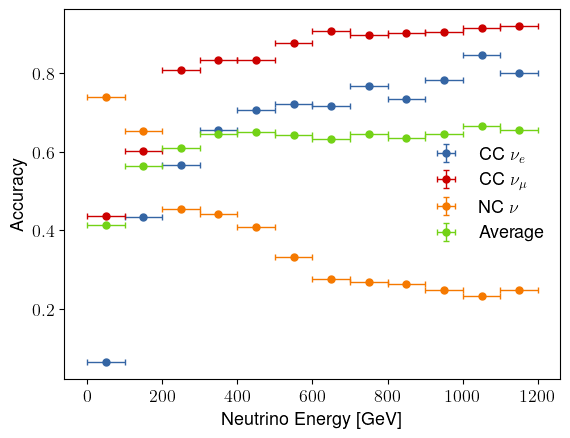

In [24]:
fig, ax = plt.subplots()
for key, label in zip(
    ["nue", "num", "nun", "average"],
    [r"CC $\nu_e$", r"CC $\nu_\mu$", r"NC $\nu$", "Average"],
):
    mplhep.histplot(
        acc_df[key].values,
        bins=nu_energy_edges * 1e-3,
        histtype="errorbar",
        xerr=True,
        label=label,
    )
ax.legend()
ax.set_xlabel(r"Neutrino Energy [GeV]")
ax.set_ylabel("Accuracy")
plt.show()

In [25]:
event_indices = np.arange(len(test_dataset))
bad_event_dict = {
    "nue_nue": event_indices[(y_true == 0) & (y_pred == 0)],
    "nue_num": event_indices[(y_true == 0) & (y_pred == 1)],
    "nue_nun": event_indices[(y_true == 0) & (y_pred == 2)],
    "num_nue": event_indices[(y_true == 1) & (y_pred == 0)],
    "num_num": event_indices[(y_true == 1) & (y_pred == 1)],
    "num_nun": event_indices[(y_true == 1) & (y_pred == 2)],
    "nun_nue": event_indices[(y_true == 2) & (y_pred == 0)],
    "nun_num": event_indices[(y_true == 2) & (y_pred == 1)],
    "nun_nun": event_indices[(y_true == 2) & (y_pred == 2)],
}

for key, indices in bad_event_dict.items():
    print(f"{key}: {len(indices)}")

nue_nue: 2446
nue_num: 797
nue_nun: 305
num_nue: 242
num_num: 2905
num_nun: 395
nun_nue: 336
nun_num: 2001
nun_nun: 1206


In [ ]:
dataset

tensor([   0.,    0.,    0., -680., -259.])


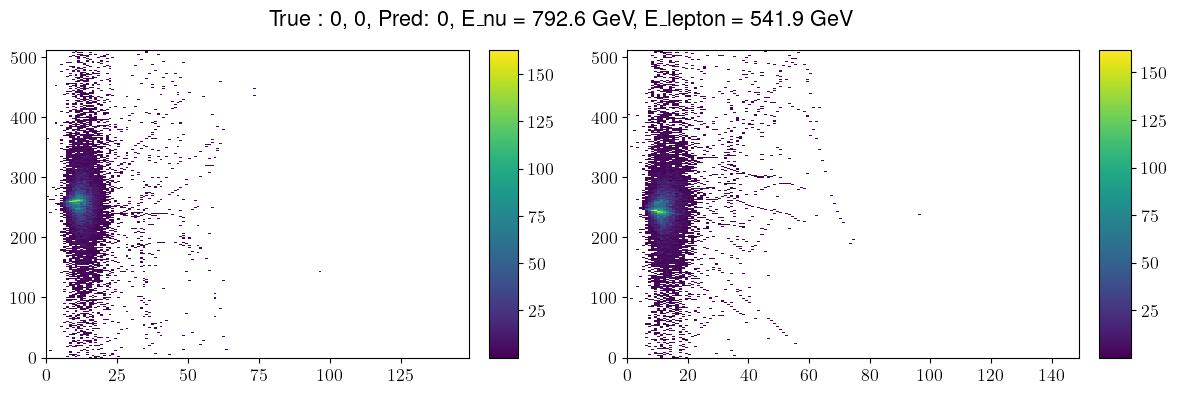

tensor([   0.,    0.,    0., -463., -358.])


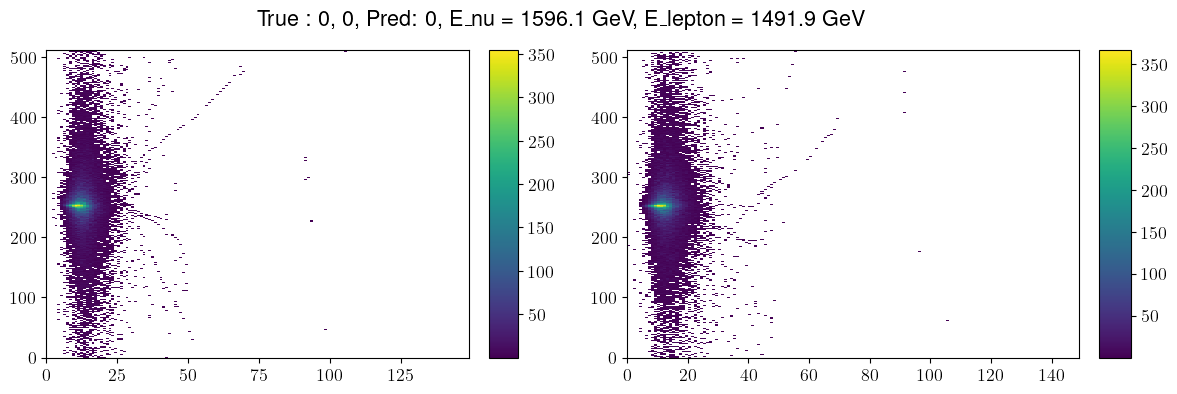

tensor([    0.,     0.,     0., -1075.,  -641.])


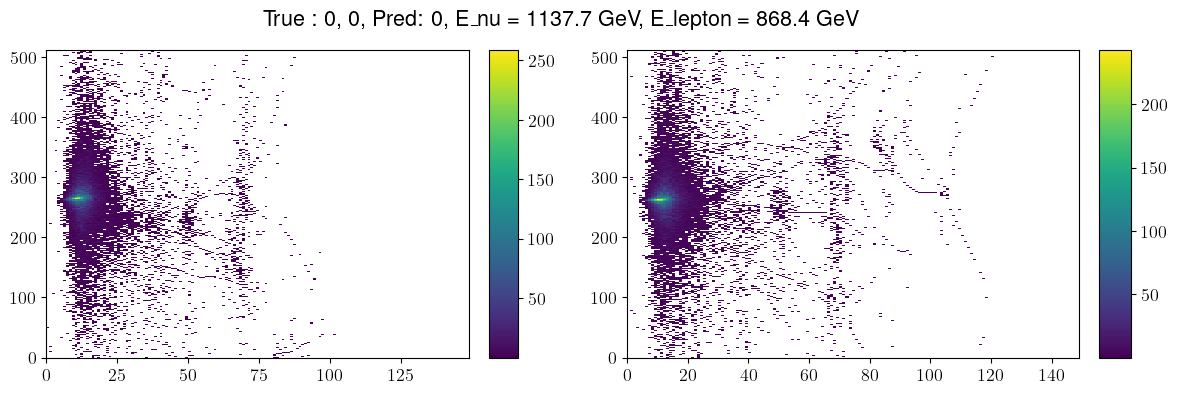

tensor([   0.,    0.,    0., -159., -398.])


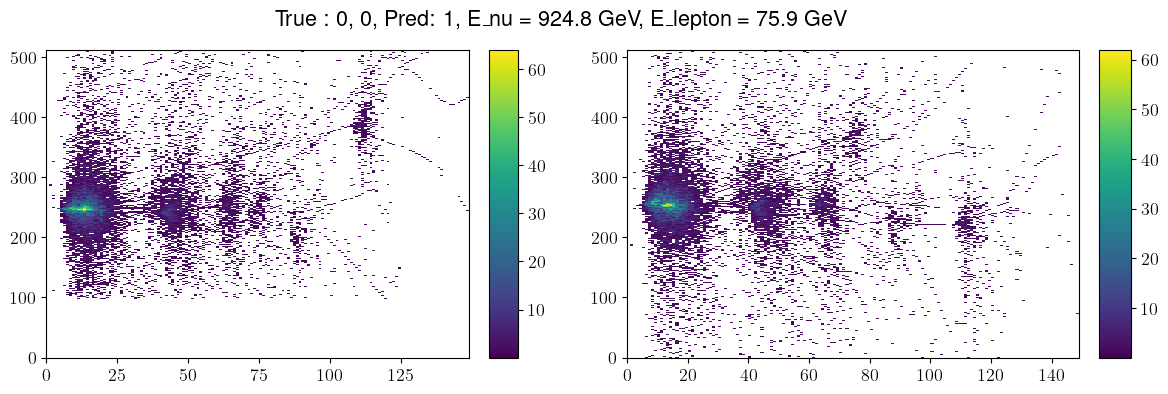

tensor([   0.,    0.,    0., -898., -277.])


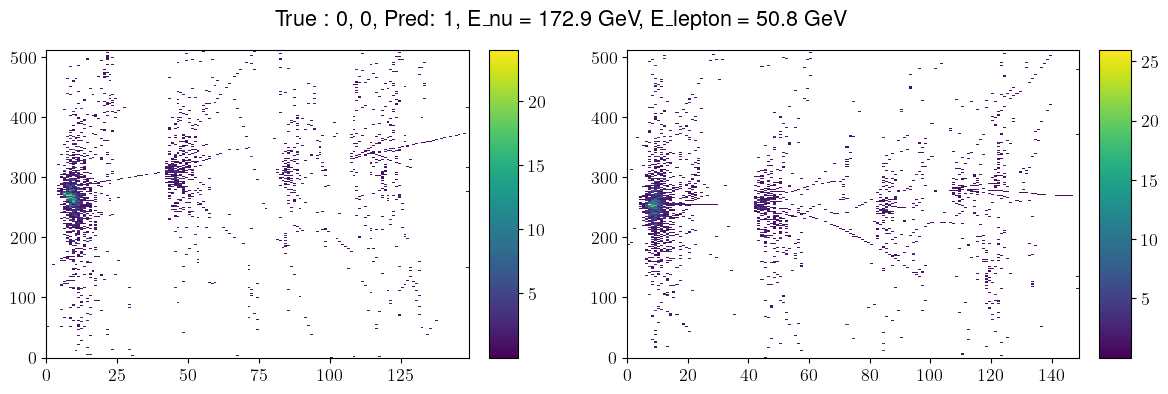

tensor([    0.,     0.,     0., -1161.,  -388.])


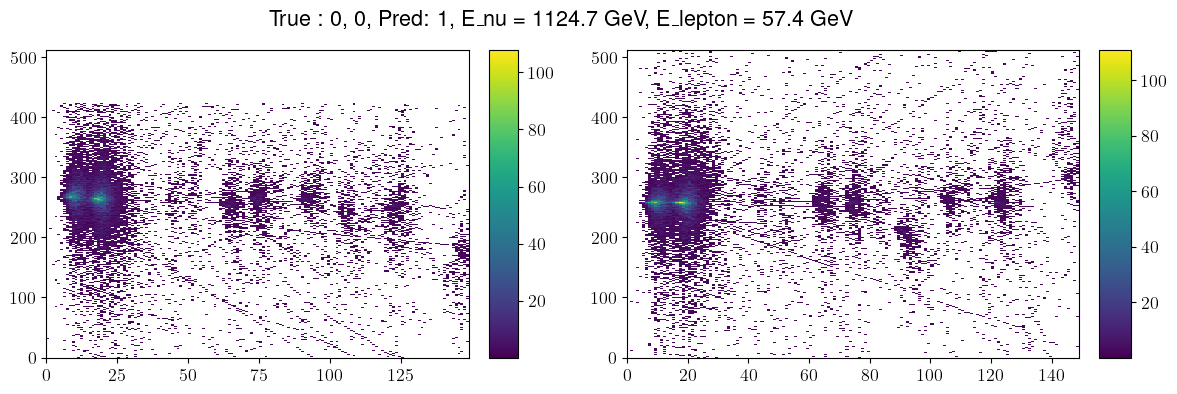

tensor([    0.,     0.,     0., -1059.,  -329.])


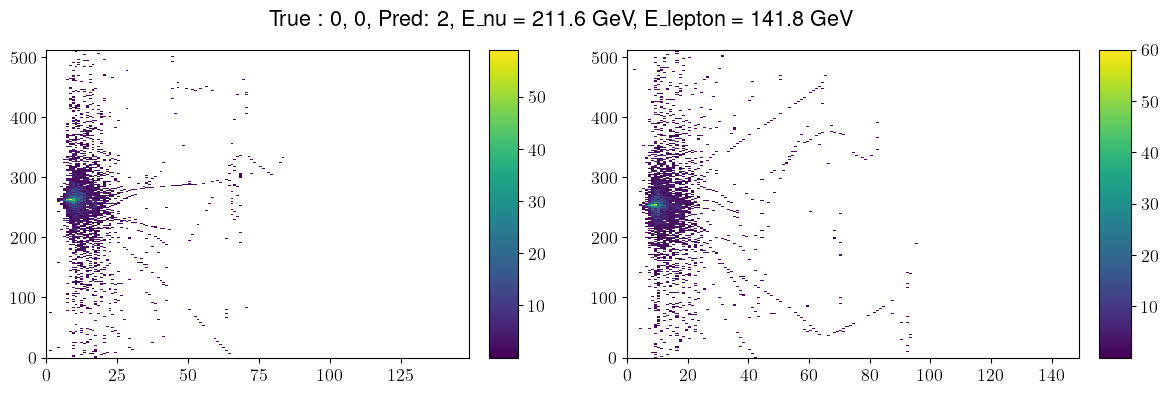

tensor([   0.,    0.,    0., -558., -258.])


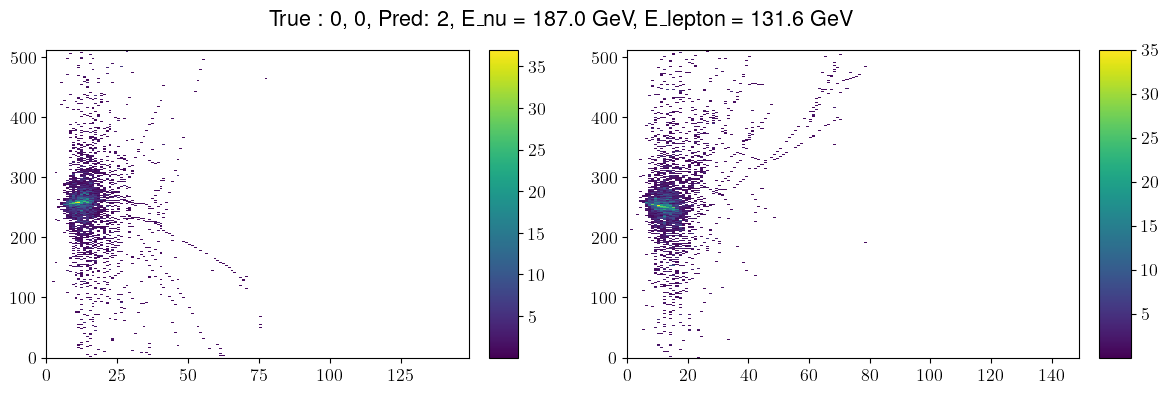

tensor([   0.,    0.,    0., -835., -401.])


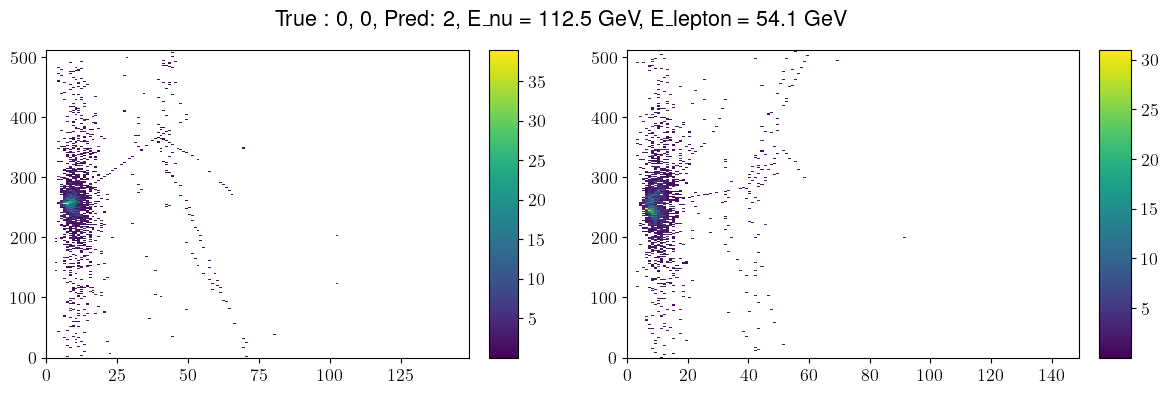

tensor([   1.0000,    1.0000,    1.0000, -722.0345, -372.7486])


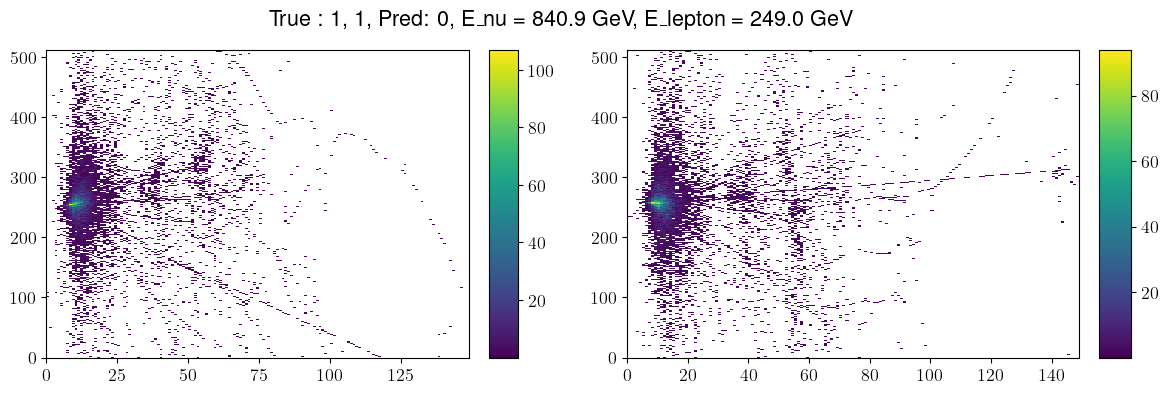

tensor([   1.0000,    1.0000,    1.0000, -416.0345, -755.7486])


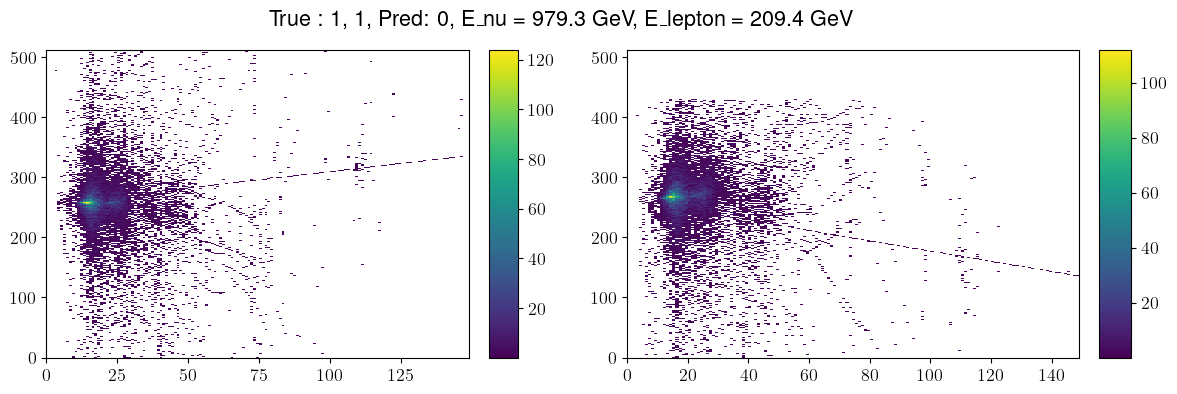

tensor([   1.0000,    1.0000,    1.0000, -903.0345, -436.7486])


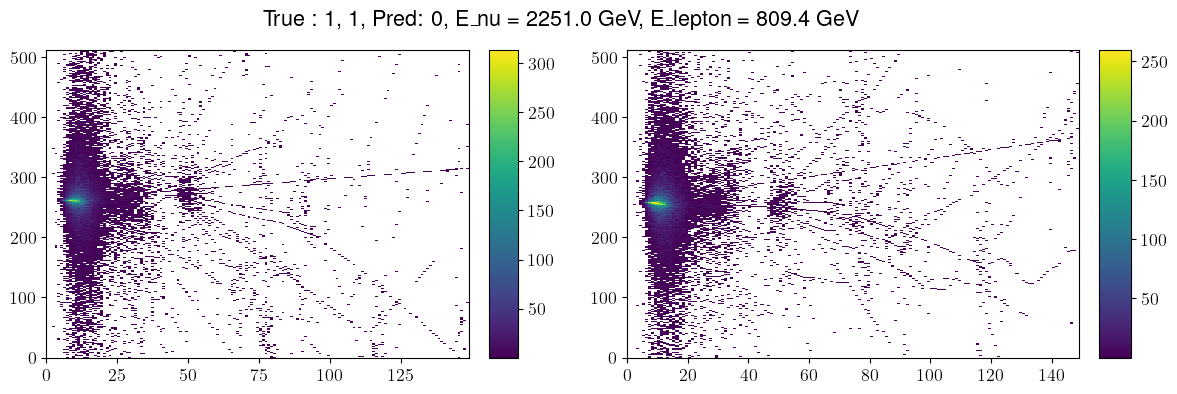

tensor([   1.0000,    1.0000,    1.0000, -777.0345, -670.7486])


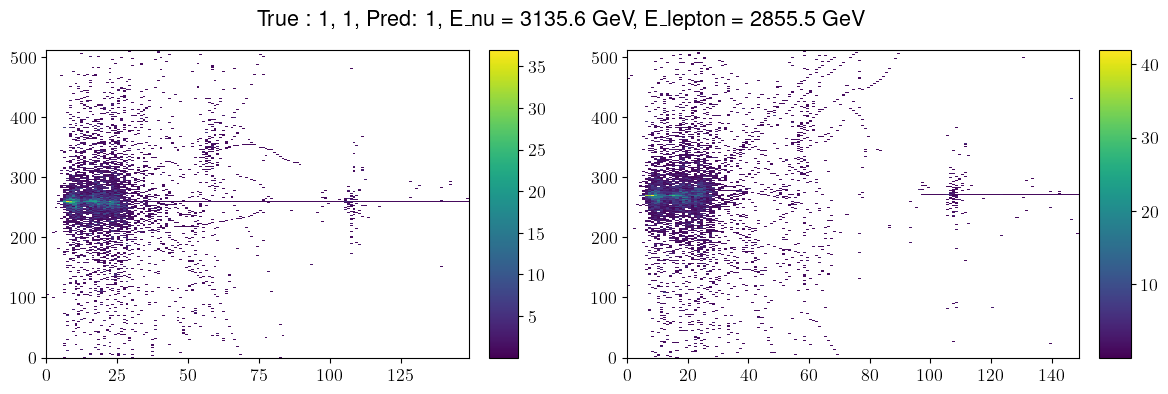

tensor([   1.0000,    1.0000,    1.0000, -432.0345, -537.7486])


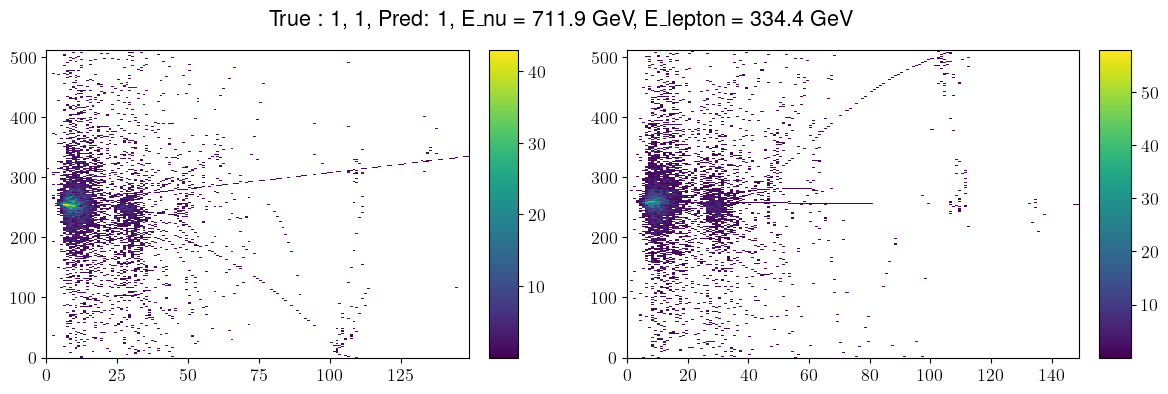

tensor([   1.0000,    1.0000,    1.0000, -365.0345, -395.7486])


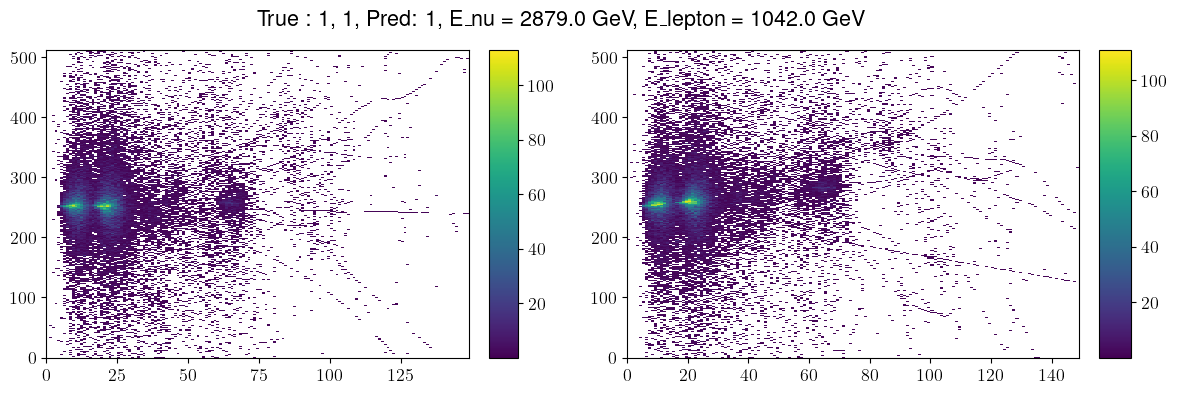

tensor([   1.0000,    1.0000,    1.0000, -989.0345, -562.7486])


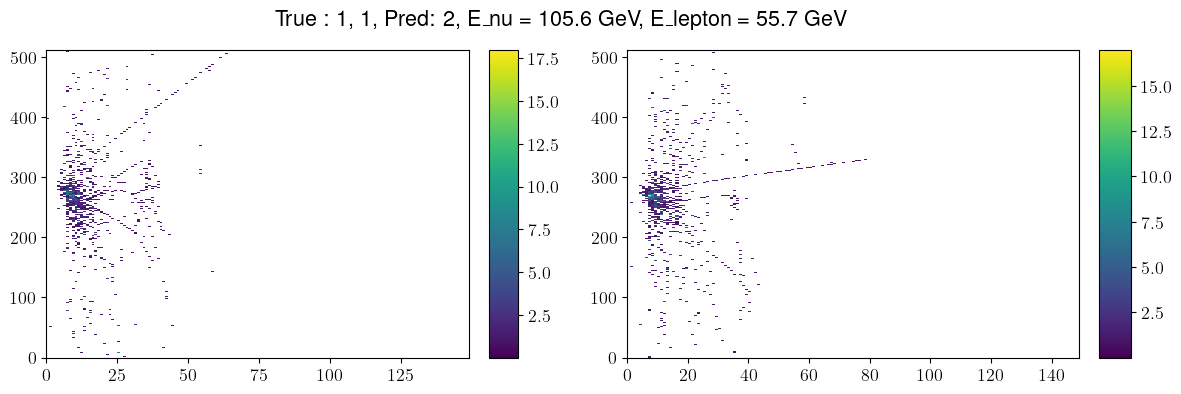

tensor([   1.0000,    1.0000,    1.0000, -849.0345, -486.7486])


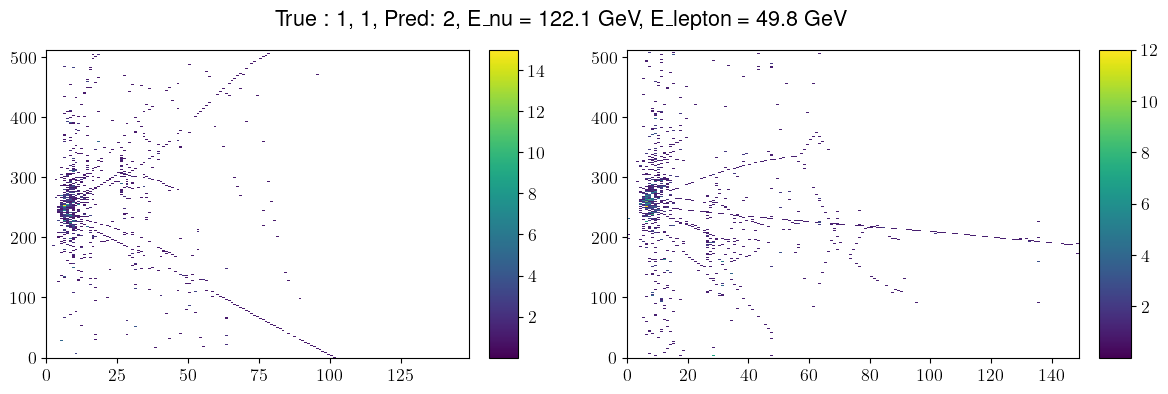

tensor([   1.0000,    1.0000,    1.0000, -392.0345, -506.7486])


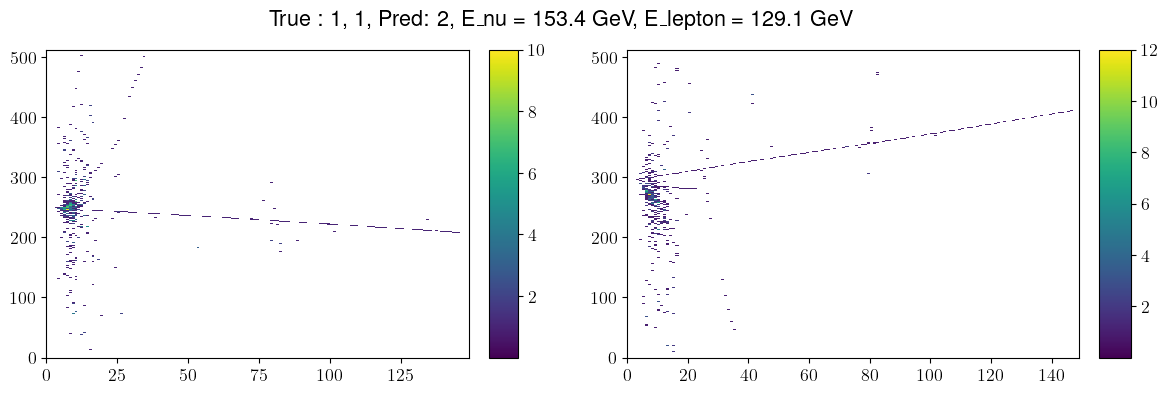

tensor([   0.,    0.,    0., -611., -204.])


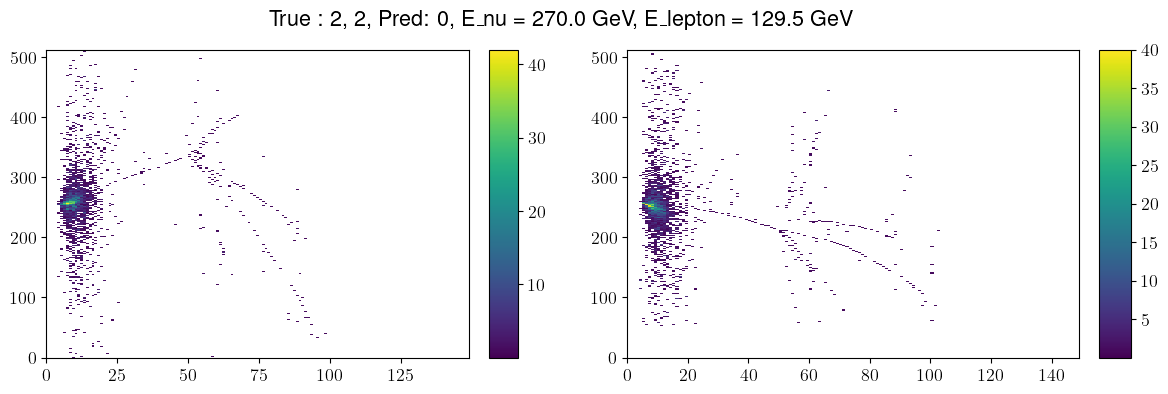

tensor([   0.,    0.,    0., -139., -838.])


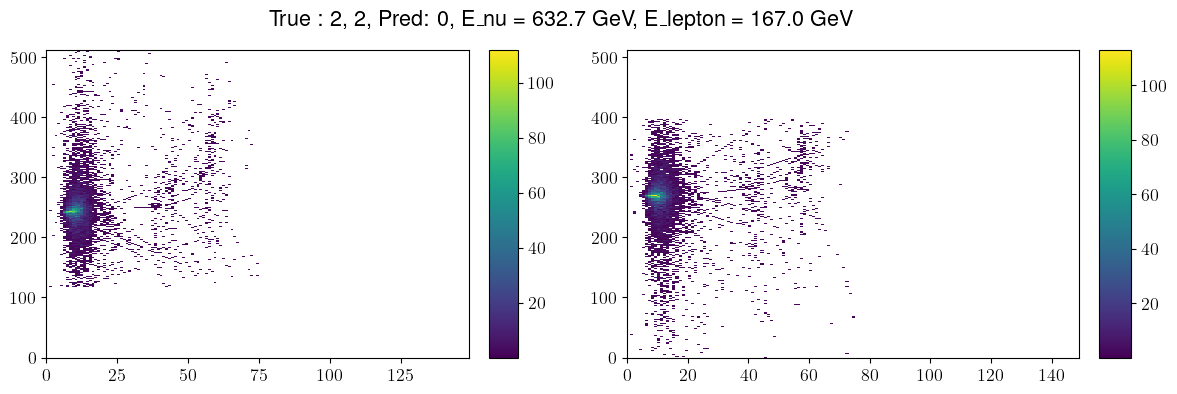

tensor([   0.,    0.,    0., -656., -493.])


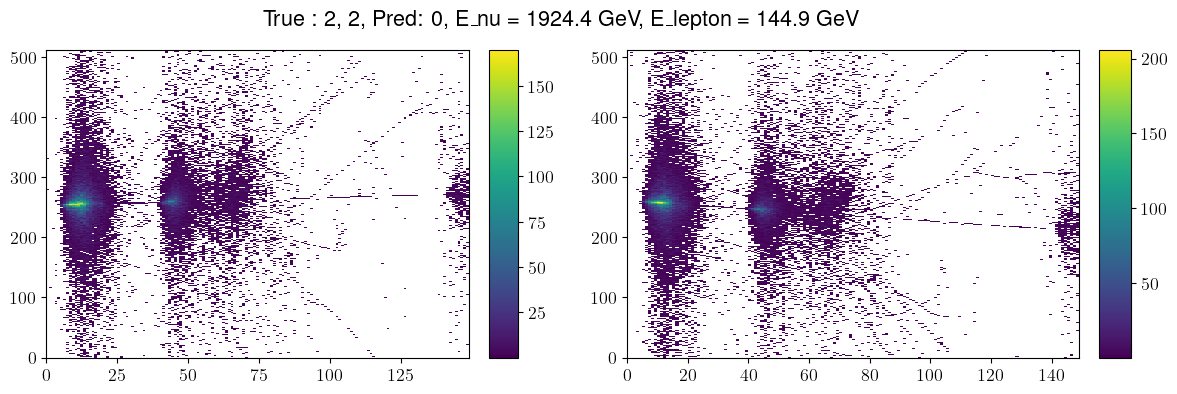

tensor([    0.,     0.,     0., -1099.,  -732.])


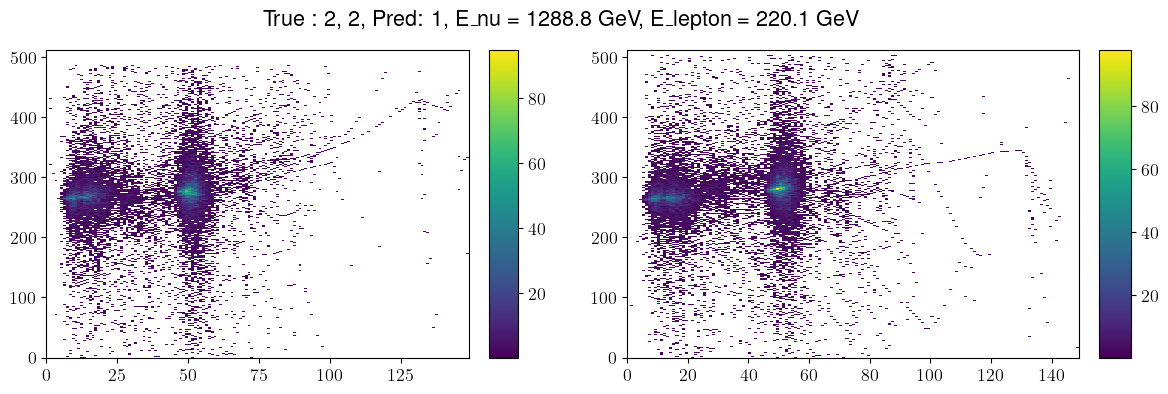

tensor([   0.,    0.,    0., -472., -550.])


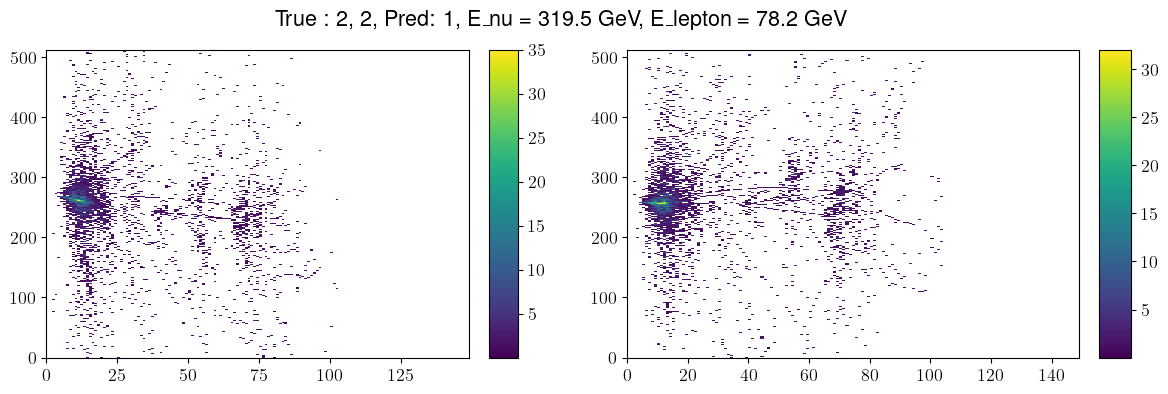

tensor([   0.,    0.,    0., -412., -234.])


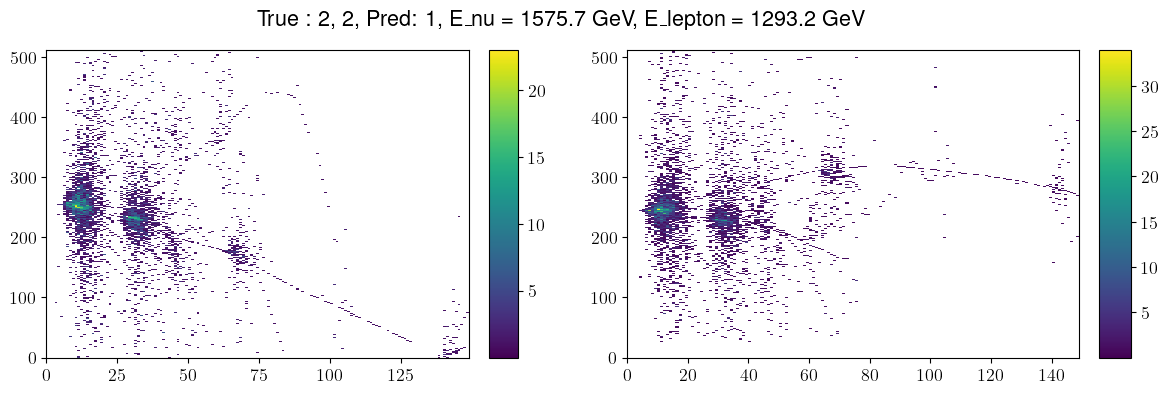

tensor([    0.,     0.,     0., -1099.,  -200.])


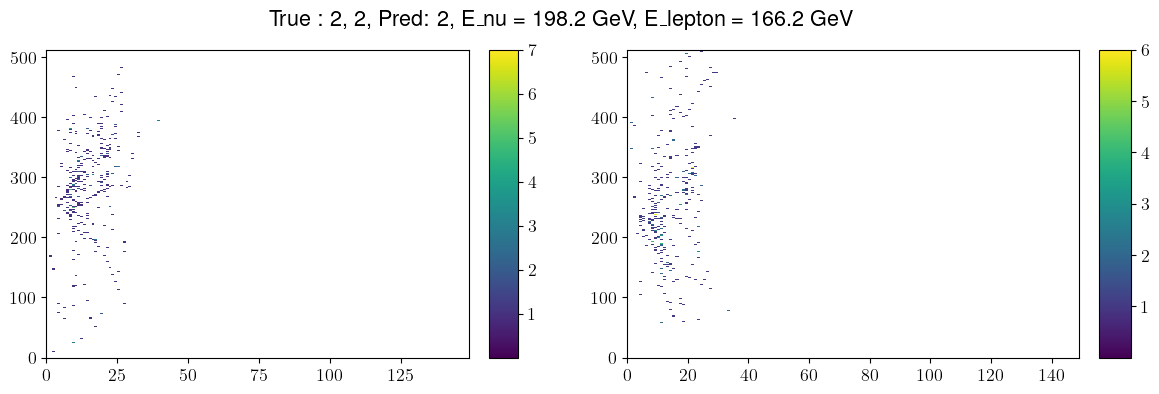

tensor([    0.,     0.,     0., -1147.,  -124.])


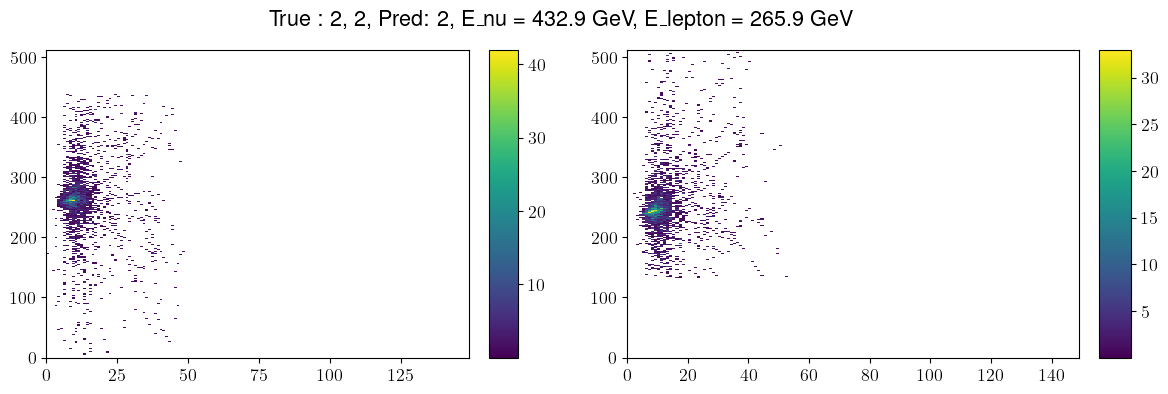

tensor([   0.,    0.,    0., -964., -356.])


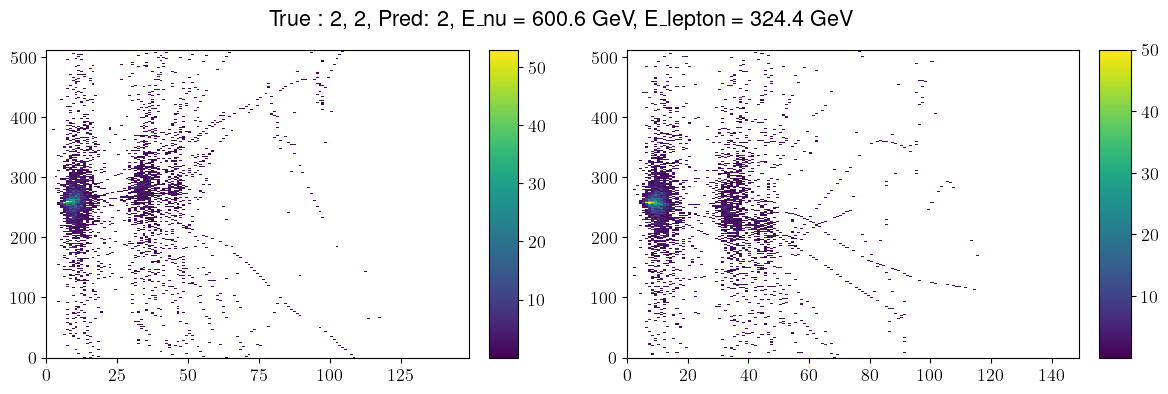

In [28]:
for key, indices in bad_event_dict.items():
    for idx in indices[:3]:
        fig, axs = plt.subplots(1, 2, figsize=(2 * 6, 4))
        (zx, zy, faser), truth = dataset[idx]
        print(faser)
        plt.suptitle(
            f"True : {truth['label']}, {y_true[idx]}, Pred: {y_pred[idx]}, E_nu = {truth['E_nu'] * 1e-3:.1f} GeV, E_lepton = {truth['E_lepton'] * 1e-3:.1f} GeV"
        )
        for i, proj in enumerate([zx, zy]):
            proj = proj.cpu().numpy()[0]
            mplhep.hist2dplot(proj, cmin=1e-3, ax=axs[i])
        plt.show()
